In [16]:
from pathlib import Path
import pandas as pd
import numpy as np

current_dir = Path.cwd()
project_root = current_dir.parent

print("Project Root:", project_root)

Project Root: c:\Users\sneha\OneDrive\Documents\CLV_Project


In [17]:
df = pd.read_csv(
    f"{project_root}/Data/customer_features.csv"
)

df.head()

,customer_id,num_orders,total_spent,avg_order_value,order_value_std,first_order_date,last_order_date,country,recency_days,customer_age_days,frequency,monetary,months_active,purchase_growth
0,12346.0,1,77183.60,77183.600000,NaN,2011-01-18 10:01:00,2011-01-18 10:01:00,United Kingdom,325,0,1,77183.60,1,0.000000
1,12347.0,7,4310.00,23.681319,23.289902,2010-12-07 14:57:00,2011-12-07 15:52:00,Iceland,1,365,7,4310.00,7,-0.683189
2,12348.0,4,1797.24,57.975484,48.514857,2010-12-16 19:09:00,2011-09-25 13:13:00,Finland,74,282,4,1797.24,4,-0.652047
3,12349.0,1,1757.55,24.076027,34.655913,2011-11-21 09:51:00,2011-11-21 09:51:00,Italy,18,0,1,1757.55,1,0.000000
4,12350.0,1,334.40,19.670588,7.275538,2011-02-02 16:01:00,2011-02-02 16:01:00,Norway,309,0,1,334.40,1,0.000000


In [18]:
df = df.fillna(0)

In [19]:
features = [
    "num_orders",
    "avg_order_value",
    "order_value_std",
    "recency_days",
    "customer_age_days",
    "months_active",
    "purchase_growth"
]

X = df[features]
y = np.log1p(df["total_spent"])

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (3470, 7)
Test size: (868, 7)


In [21]:
from sklearn.ensemble import GradientBoostingRegressor

model = GradientBoostingRegressor(random_state=42)
model.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [22]:
preds_log = model.predict(X_test)

preds = np.expm1(preds_log)
y_test_actual = np.expm1(y_test)

from sklearn.metrics import r2_score, mean_squared_error

r2 = r2_score(y_test_actual, preds)
rmse = np.sqrt(mean_squared_error(y_test_actual, preds))

print("R²:", r2)
print("RMSE:", rmse)

R²: 0.5633885662877011
RMSE: 6687.877967567766


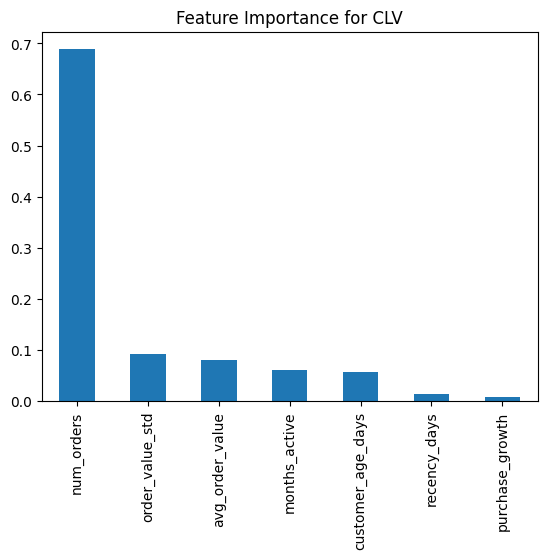

In [23]:
import matplotlib.pyplot as plt
import pandas as pd

importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

importance.plot(kind="bar")
plt.title("Feature Importance for CLV")
plt.show()

In [24]:
import pickle
import os

# create models folder if not exists
model_dir = f"{project_root}/models"
os.makedirs(model_dir, exist_ok=True)

# save trained model
model_path = f"{model_dir}/clv_model.pkl"

with open(model_path, "wb") as f:
    pickle.dump(model, f)

print("Model saved successfully at:", model_path)

Model saved successfully at: c:\Users\sneha\OneDrive\Documents\CLV_Project/models/clv_model.pkl
